# Homework 1 - Question 3
## Multi-class Classification with Logistic Regression (OvA, OvO, Softmax)

This notebook solves Question 3 end-to-end using three multi-class strategies:
- One-vs-All (OvA)
- One-vs-One (OvO)
- Softmax Regression

Workflow in this notebook:
1. Load and inspect the wine dataset.
2. Split data with stratification (75% train / 25% test).
3. Clean data using **training-only statistics** (avoid data leakage).
4. Train and compare OvA, OvO, and Softmax models.
5. Repeat with and without outlier removal to measure performance impact.

Goal: understand both the implementation and the mathematical idea behind each cell.


### Cell 1 - Imports and Global Configuration
This cell imports required libraries and defines constants used in all later cells.

Why these constants matter:
- `RANDOM_STATE = 42`: ensures reproducible splits and synthetic fallback data.
- `TEST_SIZE = 0.25`: enforces the assignment split rule (75% train, 25% test).
- `Z_THRESHOLD = 2.75`: threshold for outlier detection using Z-score.
- `EPS = 1e-15`: numerical stability constant to avoid `log(0)` in cross-entropy.

From this point onward, every function/class reads these same constants, so behavior stays consistent.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

DATA_PATH = 'wine_dataset.csv'
TARGET_COL = 'class_label'
RANDOM_STATE = 42
TEST_SIZE = 0.25
Z_THRESHOLD = 2.75
EPS = 1e-15


### Cell 2 - Data Loading
This cell reads `wine_dataset.csv`, aligns column names with the expected schema, and returns a dataframe.

What happens inside:
- The expected feature list is defined explicitly.
- If the file exists, it is loaded and columns are validated/renamed.
- If the file is missing, synthetic data is generated so the notebook can still run.

Why this matters:
- Keeps input format consistent before preprocessing and modeling.
- Prevents downstream failures caused by missing/incorrect columns.


In [2]:
def load_data(filename=DATA_PATH):
    columns = [
        'alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
        'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
        'proanthocyanins', 'color_intensity', 'hue',
        'od280_od315_of_diluted_wines', 'proline', 'class_label'
    ]

    try:
        df = pd.read_csv(filename)
        if len(df.columns) == len(columns):
            df.columns = columns
        print(f'Dataset loaded successfully: {df.shape}')
    except FileNotFoundError:
        print("Warning: 'wine_dataset.csv' not found. Generating dummy data for demonstration.")
        np.random.seed(RANDOM_STATE)
        data = np.random.rand(178, 13)
        labels = np.random.randint(0, 3, 178)
        df = pd.DataFrame(data, columns=columns[:-1])
        df['class_label'] = labels

    return df


### Cell 3 - Descriptive Statistics (Q3.2.1)
This cell reports mean and standard deviation for each feature, only for interpretation.

Formulas:

$$
\mu_j = \frac{1}{n}\sum_{i=1}^{n} x_{ij}
$$

$$
\sigma_j = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(x_{ij} - \mu_j)^2}
$$

Interpretation:
- Mean tells the central level of each feature.
- Standard deviation shows spread/variability.

Important: these values are descriptive in this cell; they are not directly used for model training here.


In [3]:
def get_descriptive_stats(df):
    print()
    print('--- 3.2.1 Descriptive Statistics (Mean & Std) ---')
    stats = df.describe().loc[['mean', 'std']]
    print(stats)
    return stats


### Cell 4 - Stratified Train/Test Split (Q3.2.3)
This cell separates features (`X`) and labels (`y`), encodes labels, then applies **stratified splitting**.

What is stratification?
- It keeps class ratios approximately the same in train and test.
- If class proportions in the full dataset are $p_k$, stratification targets similar $p_k$ in each split.

Split rule used here:
- Train size: $75\%$
- Test size: $25\%$

Why this matters:
- Prevents biased evaluation when classes are uneven.
- Makes train/test comparison more reliable.


In [4]:
def split_data(df):
    print()
    print('--- 3.2.3 Stratified Split (75% Train, 25% Test) ---')
    X = df.drop(TARGET_COL, axis=1)
    y = df[TARGET_COL]

    encoder = LabelEncoder()
    y_encoded = encoder.fit_transform(y)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y_encoded,
        test_size=TEST_SIZE,
        stratify=y_encoded,
        random_state=RANDOM_STATE
    )
    return X_train, X_test, y_train, y_test, encoder


### Cell 5 - Cleaning and Min-Max Normalization (Q3.2.4, Q3.2.5, Q3.2.6)
This cell preprocesses data using **training-only statistics**.

Step-by-step logic:
1. Remove duplicate rows from training data.
2. Fill missing values using training means.
3. Detect outliers in training set with Z-score.
4. Apply Min-Max normalization using train min/max.

Key formulas:

Z-score (for outlier detection):
$$
z_{ij} = \frac{x_{ij} - \mu_j}{\sigma_j}
$$
Rows with any $|z_{ij}| > 2.75$ are treated as outliers.

Min-Max normalization:
$$
x'_{ij} = \frac{x_{ij} - \min_j}{\max_j - \min_j}
$$

Why training-only statistics are required:
- Prevents **data leakage** from test set into preprocessing.
- Keeps evaluation honest (test data must stay unseen during fitting).


In [5]:
def preprocess_data(X_train, y_train, X_test, remove_outliers=True):
    train_df = pd.concat([X_train, pd.Series(y_train, name='target', index=X_train.index)], axis=1)

    initial_len = len(train_df)
    train_df = train_df.drop_duplicates()
    removed_dupes = initial_len - len(train_df)
    if removed_dupes > 0:
        print(f'Removed {removed_dupes} duplicate samples from training set.')

    X_train_clean = train_df.drop('target', axis=1)
    y_train_clean = train_df['target'].values

    train_means = X_train_clean.mean()
    X_train_clean = X_train_clean.fillna(train_means)
    X_test_clean = X_test.fillna(train_means)

    outliers_count = 0
    if remove_outliers:
        z_scores = np.abs((X_train_clean - X_train_clean.mean()) / X_train_clean.std())
        outlier_mask = (z_scores > Z_THRESHOLD).any(axis=1)
        outliers_count = int(outlier_mask.sum())

        print()
        print('--- 3.2.5 Outlier Detection ---')
        print(f'Outliers detected (Z > {Z_THRESHOLD}): {outliers_count}')

        X_train_clean = X_train_clean[~outlier_mask]
        y_train_clean = y_train_clean[~outlier_mask]
        print(f'Training samples after outlier removal: {len(X_train_clean)}')
    else:
        print()
        print('--- Skipping Outlier Removal for Comparison ---')

    min_val = X_train_clean.min()
    max_val = X_train_clean.max()
    denom = (max_val - min_val).replace(0, 1)

    X_train_norm = (X_train_clean - min_val) / denom
    X_test_norm = (X_test_clean - min_val) / denom

    return X_train_norm.values, y_train_clean, X_test_norm.values, outliers_count


### Cell 6 - Utility Plot for Confusion Matrix
This helper visualizes classification quality using a confusion matrix.

For class indices $0,1,\dots,K-1$, matrix entry $C_{ij}$ means:
- true class is $i$
- predicted class is $j$

Reading the matrix:
- Large diagonal values ($C_{ii}$) indicate correct predictions.
- Off-diagonal values indicate class confusions.

This is especially useful in multi-class settings because accuracy alone can hide which classes are being confused.


In [6]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()


### Cell 7 - Binary Logistic Regression (from scratch)
This is the base classifier used inside OvA and OvO.

Model:
$$
z = w^T x + b
$$
$$
\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

Loss (binary cross-entropy):
$$
J = -\frac{1}{m}\sum_{i=1}^{m}\left[y_i\log(\hat{y}_i) + (1-y_i)\log(1-\hat{y}_i)\right]
$$

Gradient updates:
$$
\frac{\partial J}{\partial w} = \frac{1}{m}X^T(\hat{y}-y), \quad
\frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=1}^{m}(\hat{y}_i-y_i)
$$

Then gradient descent is applied:
$$
w \leftarrow w - \eta\frac{\partial J}{\partial w}, \quad b \leftarrow b - \eta\frac{\partial J}{\partial b}
$$

The class stores loss per iteration and a convergence iteration for analysis.


In [7]:
class BinaryLogisticRegression:
    def __init__(self, learning_rate=0.1, iterations=2000, tol=1e-5):
        self.lr = learning_rate
        self.iterations = iterations
        self.tol = tol
        self.weights = None
        self.bias = None
        self.loss_history = []
        self.converged_iter = None

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0.0
        self.loss_history = []

        for i in range(self.iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear_model)

            y_pred_clipped = np.clip(y_pred, EPS, 1 - EPS)
            loss = -np.mean(y * np.log(y_pred_clipped) + (1 - y) * np.log(1 - y_pred_clipped))
            self.loss_history.append(loss)

            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            if i > 0 and abs(self.loss_history[-2] - self.loss_history[-1]) < self.tol:
                self.converged_iter = i
                break

        if self.converged_iter is None:
            self.converged_iter = self.iterations

    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_model)

    def predict(self, X):
        return np.array([1 if p > 0.5 else 0 for p in self.predict_proba(X)])


### Cell 8 - Softmax Regression (from scratch)
Softmax regression is logistic regression generalized to multi-class classification.

For class logits:
$$
z_k = w_k^T x + b_k
$$

Softmax probability of class $k$:
$$
P(y=k\mid x) = \frac{e^{z_k}}{\sum_{c=1}^{K} e^{z_c}}
$$

Multi-class cross-entropy loss:
$$
J = -\frac{1}{m}\sum_{i=1}^{m}\sum_{k=1}^{K} y_{ik}\log(\hat{p}_{ik})
$$
where $y_{ik}$ is one-hot encoded.

Optimization:
- compute probabilities with softmax,
- compute gradients,
- update weight matrix and bias vector by gradient descent.

This gives one unified model for all classes (unlike OvA/OvO which combine multiple binary models).


In [8]:
class SoftmaxRegression:
    def __init__(self, learning_rate=0.1, iterations=2000, tol=1e-5):
        self.lr = learning_rate
        self.iterations = iterations
        self.tol = tol
        self.weights = None
        self.bias = None
        self.loss_history = []
        self.converged_iter = None

    def softmax(self, z):
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def one_hot(self, y, n_classes):
        return np.eye(n_classes)[y]

    def fit(self, X, y):
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))

        self.weights = np.zeros((n_features, n_classes))
        self.bias = np.zeros(n_classes)
        y_encoded = self.one_hot(y, n_classes)
        self.loss_history = []

        for i in range(self.iterations):
            logits = np.dot(X, self.weights) + self.bias
            y_pred = self.softmax(logits)

            y_pred_clipped = np.clip(y_pred, EPS, 1 - EPS)
            loss = -np.mean(np.sum(y_encoded * np.log(y_pred_clipped), axis=1))
            self.loss_history.append(loss)

            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y_encoded))
            db = (1 / n_samples) * np.sum(y_pred - y_encoded, axis=0)

            self.weights -= self.lr * dw
            self.bias -= self.lr * db

            if i > 0 and abs(self.loss_history[-2] - self.loss_history[-1]) < self.tol:
                self.converged_iter = i
                break

        if self.converged_iter is None:
            self.converged_iter = self.iterations

    def predict(self, X):
        logits = np.dot(X, self.weights) + self.bias
        probs = self.softmax(logits)
        return np.argmax(probs, axis=1)


### Cell 9 - OvA Strategy (One-vs-All)
**Idea:** convert a $K$-class problem into $K$ binary problems.

How it works:
- For each class $k$, train one binary model:
  - positive class: samples with label $k$
  - negative class: all other samples
- So total models trained: $K$.

Prediction rule:
- Each model outputs a probability score for its class.
- Choose the class with the largest score:
$$
\hat{y} = \arg\max_k \hat{p}_k
$$

Intuition:
- Every classifier answers: “Is this sample class $k$ or not?”
- Final decision picks the most confident “yes”.


In [9]:
class OvAClassifier:
    def __init__(self, n_classes, learning_rate=0.1, iterations=2000, tol=1e-5):
        self.models = []
        self.n_classes = n_classes
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.tol = tol

    def fit(self, X, y):
        self.models = []
        print()
        print('Training OvA Models:')
        for i in range(self.n_classes):
            print(f'  - Training Class {i} vs All')
            y_binary = np.where(y == i, 1, 0)
            model = BinaryLogisticRegression(
                learning_rate=self.learning_rate,
                iterations=self.iterations,
                tol=self.tol
            )
            model.fit(X, y_binary)
            self.models.append(model)

    def predict(self, X):
        probs = np.zeros((X.shape[0], self.n_classes))
        for i, model in enumerate(self.models):
            probs[:, i] = model.predict_proba(X)
        return np.argmax(probs, axis=1)


### Cell 10 - OvO Strategy (One-vs-One)
**Idea:** train a binary classifier for every pair of classes.

How many models?
$$
\binom{K}{2} = \frac{K(K-1)}{2}
$$

For each pair $(i,j)$:
- keep only samples from classes $i$ and $j$,
- train one binary classifier to separate them.

Prediction rule (voting):
- Every pairwise model casts one vote for either class $i$ or $j$.
- Predicted class is the one with most votes:
$$
\hat{y} = \arg\max_k \text{votes}_k
$$

Intuition:
- OvO asks many “head-to-head” questions between class pairs.
- It often works well when pairwise boundaries are simpler than global boundaries.


In [10]:
class OvOClassifier:
    def __init__(self, n_classes, learning_rate=0.1, iterations=2000, tol=1e-5):
        self.models = []
        self.n_classes = n_classes
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.tol = tol

    def fit(self, X, y):
        self.models = []
        classes = np.unique(y)
        print()
        print('Training OvO Models:')

        for i in range(len(classes)):
            for j in range(i + 1, len(classes)):
                c1, c2 = classes[i], classes[j]
                print(f'  - Training Class {c1} vs Class {c2}')

                mask = (y == c1) | (y == c2)
                X_pair = X[mask]
                y_pair = y[mask]
                y_binary = np.where(y_pair == c2, 1, 0)

                model = BinaryLogisticRegression(
                    learning_rate=self.learning_rate,
                    iterations=self.iterations,
                    tol=self.tol
                )
                model.fit(X_pair, y_binary)
                self.models.append(((c1, c2), model))

    def predict(self, X):
        votes = np.zeros((X.shape[0], self.n_classes))

        for (c1, c2), model in self.models:
            pred_binary = model.predict(X)
            for idx, p in enumerate(pred_binary):
                if p == 0:
                    votes[idx, c1] += 1
                else:
                    votes[idx, c2] += 1

        return np.argmax(votes, axis=1)


### Cell 11 - Experiment Runner
This cell runs one complete experiment under a selected preprocessing condition:
- `remove_outliers=True`, or
- `remove_outliers=False`.

Inside one run it does:
1. Load + split + preprocess data.
2. Train OvA, OvO, and Softmax models.
3. Compute test accuracy for all three.
4. Plot loss curves and confusion matrices.
5. Return accuracy values for later comparison.

So this function is the central pipeline used twice in the final execution cell.


In [11]:
def run_experiment(outlier_removal_flag):
    print()
    print('=' * 50)
    print(f'EXPERIMENT: Remove Outliers = {outlier_removal_flag}')
    print('=' * 50)

    df = load_data()
    X_train_raw, X_test_raw, y_train_raw, y_test, _ = split_data(df)
    X_train, y_train, X_test, outliers_removed = preprocess_data(
        X_train_raw,
        y_train_raw,
        X_test_raw,
        remove_outliers=outlier_removal_flag
    )

    num_classes = len(np.unique(y_train_raw))

    ova = OvAClassifier(num_classes)
    ova.fit(X_train, y_train)
    ova_pred = ova.predict(X_test)
    ova_acc = accuracy_score(y_test, ova_pred)

    plt.figure(figsize=(12, 3))
    plt.suptitle(f'OvA Loss Curves (Outliers Removed: {outlier_removal_flag})')
    for i, model in enumerate(ova.models):
        plt.subplot(1, num_classes, i + 1)
        plt.plot(model.loss_history)
        plt.title(f'Class {i} vs Rest\nConv: {model.converged_iter} iters')
        plt.xlabel('Iteration')
        plt.ylabel('Loss')
    plt.tight_layout()
    plt.show()
    plot_confusion_matrix(y_test, ova_pred, f'OvA Confusion Matrix (Outliers: {outlier_removal_flag})')

    ovo = OvOClassifier(num_classes)
    ovo.fit(X_train, y_train)
    ovo_pred = ovo.predict(X_test)
    ovo_acc = accuracy_score(y_test, ovo_pred)
    plot_confusion_matrix(y_test, ovo_pred, f'OvO Confusion Matrix (Outliers: {outlier_removal_flag})')

    print()
    print('Training Softmax Regression...')
    softmax = SoftmaxRegression(learning_rate=0.1, iterations=2000, tol=1e-5)
    softmax.fit(X_train, y_train)
    sm_pred = softmax.predict(X_test)
    sm_acc = accuracy_score(y_test, sm_pred)

    plt.figure(figsize=(6, 4))
    plt.plot(softmax.loss_history)
    plt.title(
        f'Softmax Regression Loss (Outliers Removed: {outlier_removal_flag})\n'
        f'Conv: {softmax.converged_iter} iters'
    )
    plt.xlabel('Iteration')
    plt.ylabel('Cross-Entropy Loss')
    plt.tight_layout()
    plt.show()
    plot_confusion_matrix(y_test, sm_pred, f'Softmax Confusion Matrix (Outliers: {outlier_removal_flag})')

    print()
    print(f'Outliers removed in this run: {outliers_removed}')
    print(f'OvA Test Accuracy:     {ova_acc:.4f}')
    print(f'OvO Test Accuracy:     {ovo_acc:.4f}')
    print(f'Softmax Test Accuracy: {sm_acc:.4f}')

    return ova_acc, ovo_acc, sm_acc


### Cell 12 - Assignment Text Answer: Normalization vs Standardization (Q3.2.7)
This cell prints a concise conceptual answer required in the report.

Normalization (Min-Max):
$$
x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
$$
- maps data to a bounded interval (usually $[0,1]$),
- sensitive to extreme values.

Standardization (Z-score):
$$
x' = \frac{x - \mu}{\sigma}
$$
- centers around 0 and scales by standard deviation,
- common when feature distributions are roughly Gaussian.

In this notebook, Min-Max is used because Question 3 explicitly asks for normalization.


In [12]:
def explain_normalization_vs_standardization():
    print()
    print('--- 3.2.7 Normalization vs Standardization ---')
    print('Normalization (Min-Max): Scales features to [0, 1] using train min/max values.')
    print('Standardization (Z-score): Centers to mean 0 and scales to standard deviation 1.')
    print('In this notebook we use normalization because Question 3 explicitly requires Min-Max scaling.')


### Cell 13 - Main Execution (With and Without Outlier Removal)
This final cell orchestrates the full homework workflow.

Execution order:
1. Load full data and print descriptive statistics.
2. Print normalization vs standardization explanation.
3. Run experiment with outlier removal.
4. Run experiment without outlier removal.
5. Print side-by-side accuracy comparison.
6. Print short complexity discussion for OvA/OvO/Softmax.

Complexity intuition:
- OvA: trains $K$ models.
- OvO: trains $\frac{K(K-1)}{2}$ models.
- Softmax: trains one multi-class model.

This gives both model-performance comparison and preprocessing-impact analysis as requested.


Dataset loaded successfully: (178, 14)

--- 3.2.1 Descriptive Statistics (Mean & Std) ---
        alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
mean  13.000618    2.336348  2.366517          19.494944  99.741573   
std    0.811827    1.117146  0.274344           3.339564  14.282484   

      total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
mean       2.295112    2.029270              0.361854         1.590899   
std        0.625851    0.998859              0.124453         0.572359   

      color_intensity       hue  od280_od315_of_diluted_wines     proline  \
mean         5.058090  0.957449                      2.611685  746.893258   
std          2.318286  0.228572                      0.709990  314.907474   

      class_label  
mean     1.938202  
std      0.775035  

--- 3.2.7 Normalization vs Standardization ---
Normalization (Min-Max): Scales features to [0, 1] using train min/max values.
Standardization (Z-score): Centers to mean 0 and scale

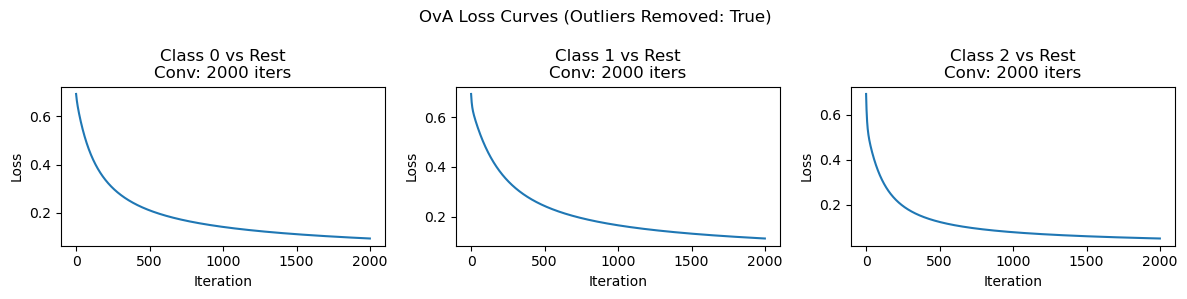

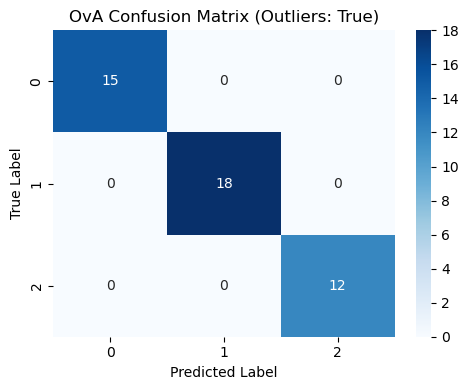


Training OvO Models:
  - Training Class 0 vs Class 1
  - Training Class 0 vs Class 2
  - Training Class 1 vs Class 2


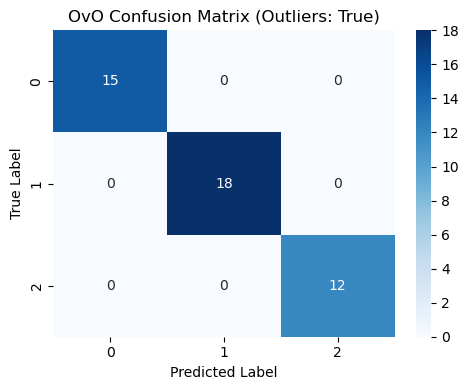


Training Softmax Regression...


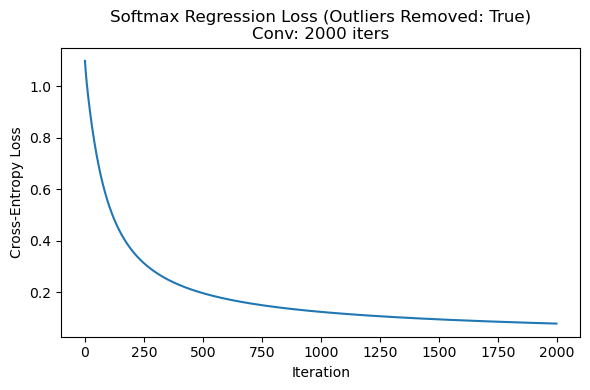

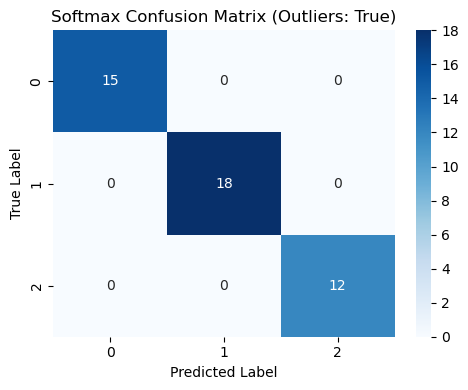


Outliers removed in this run: 11
OvA Test Accuracy:     1.0000
OvO Test Accuracy:     1.0000
Softmax Test Accuracy: 1.0000

>>> STARTING EXPERIMENT 2: WITHOUT OUTLIER REMOVAL <<<

EXPERIMENT: Remove Outliers = False
Dataset loaded successfully: (178, 14)

--- 3.2.3 Stratified Split (75% Train, 25% Test) ---

--- Skipping Outlier Removal for Comparison ---

Training OvA Models:
  - Training Class 0 vs All
  - Training Class 1 vs All
  - Training Class 2 vs All


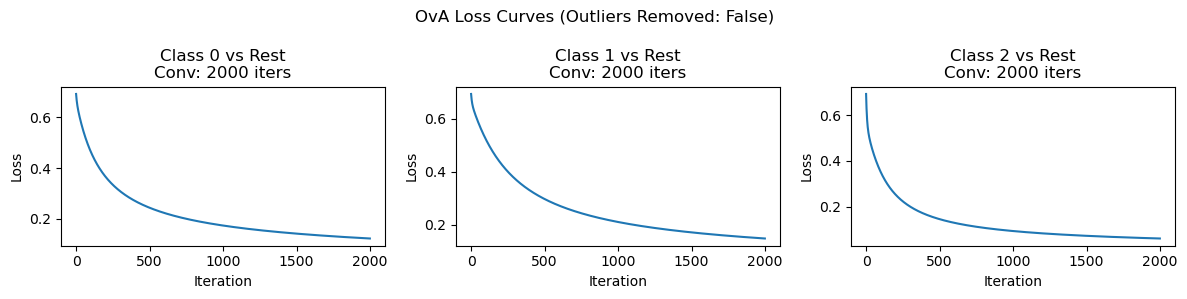

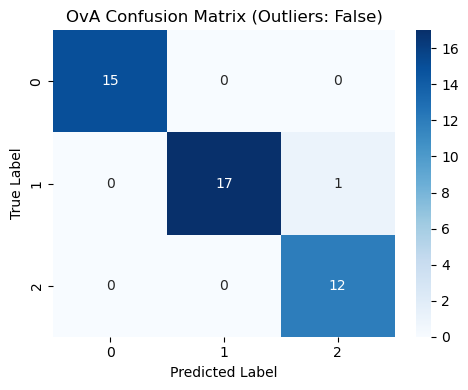


Training OvO Models:
  - Training Class 0 vs Class 1
  - Training Class 0 vs Class 2
  - Training Class 1 vs Class 2


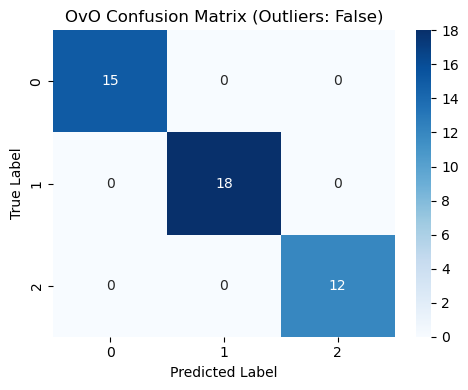


Training Softmax Regression...


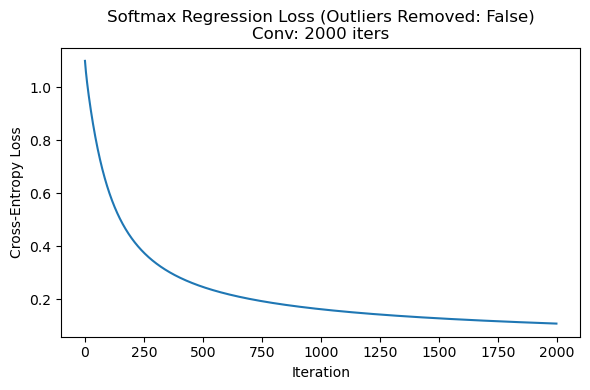

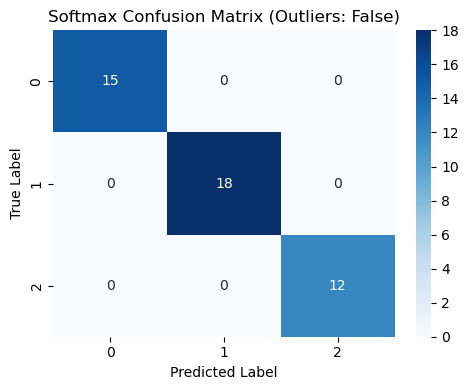


Outliers removed in this run: 0
OvA Test Accuracy:     0.9778
OvO Test Accuracy:     1.0000
Softmax Test Accuracy: 1.0000

3.3.6 IMPACT OF OUTLIER REMOVAL ANALYSIS
Model    | Acc (Clean) | Acc (Dirty) | Improvement
OvA      | 1.0000      | 0.9778      | 0.0222
OvO      | 1.0000      | 1.0000      | 0.0000
Softmax  | 1.0000      | 1.0000      | 0.0000

--- 3.3.5 Complexity Analysis ---
OvA: Trains K binary models. Complexity grows linearly with number of classes.
OvO: Trains K(K-1)/2 models. Complexity grows quadratically with number of classes.
Softmax: Trains one multiclass model with K outputs. Usually efficient for multiclass tasks.


In [13]:
if __name__ == '__main__':
    df_full = load_data()
    get_descriptive_stats(df_full)
    explain_normalization_vs_standardization()

    print()
    print('>>> STARTING EXPERIMENT 1: WITH OUTLIER REMOVAL <<<')
    acc_with_ova, acc_with_ovo, acc_with_sm = run_experiment(outlier_removal_flag=True)

    print()
    print('>>> STARTING EXPERIMENT 2: WITHOUT OUTLIER REMOVAL <<<')
    acc_no_ova, acc_no_ovo, acc_no_sm = run_experiment(outlier_removal_flag=False)

    print()
    print('=' * 50)
    print('3.3.6 IMPACT OF OUTLIER REMOVAL ANALYSIS')
    print('=' * 50)
    print('Model    | Acc (Clean) | Acc (Dirty) | Improvement')
    print(f'OvA      | {acc_with_ova:.4f}      | {acc_no_ova:.4f}      | {acc_with_ova - acc_no_ova:.4f}')
    print(f'OvO      | {acc_with_ovo:.4f}      | {acc_no_ovo:.4f}      | {acc_with_ovo - acc_no_ovo:.4f}')
    print(f'Softmax  | {acc_with_sm:.4f}      | {acc_no_sm:.4f}      | {acc_with_sm - acc_no_sm:.4f}')

    print()
    print('--- 3.3.5 Complexity Analysis ---')
    print('OvA: Trains K binary models. Complexity grows linearly with number of classes.')
    print('OvO: Trains K(K-1)/2 models. Complexity grows quadratically with number of classes.')
    print('Softmax: Trains one multiclass model with K outputs. Usually efficient for multiclass tasks.')
